Initial Data:
          Date Product     Category  Price  Quantity Region
0  2024-01-01  Laptop  Electronics  55000       2.0  South
1  2024-01-02   Phone  Electronics  20000       3.0  North
2  2024-01-03   Shirt     Clothing   1500       5.0   East
3  2024-01-04   Shoes     Footwear   3000       4.0   West
4  2024-01-05   Watch  Accessories   5000       1.0  South

Missing Values:
 Date        0
Product     0
Category    0
Price       0
Quantity    5
Region      0
dtype: int64

Cleaned Data:
         Date Product     Category  Price  Quantity Region     Total
0 2024-01-01  Laptop  Electronics  55000       2.0  South  110000.0
1 2024-01-02   Phone  Electronics  20000       3.0  North   60000.0
2 2024-01-03   Shirt     Clothing   1500       5.0   East    7500.0
3 2024-01-04   Shoes     Footwear   3000       4.0   West   12000.0
4 2024-01-05   Watch  Accessories   5000       1.0  South    5000.0


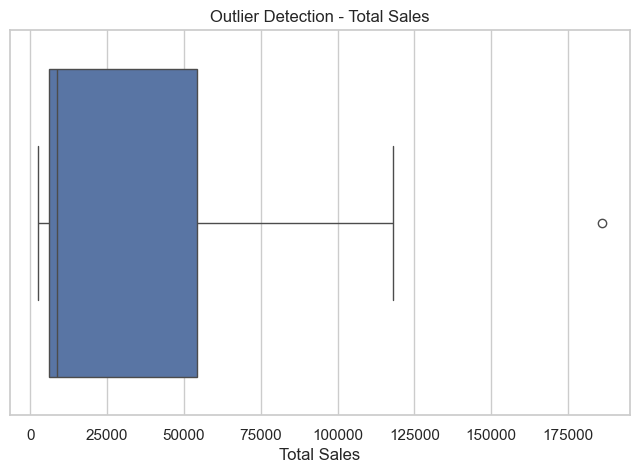

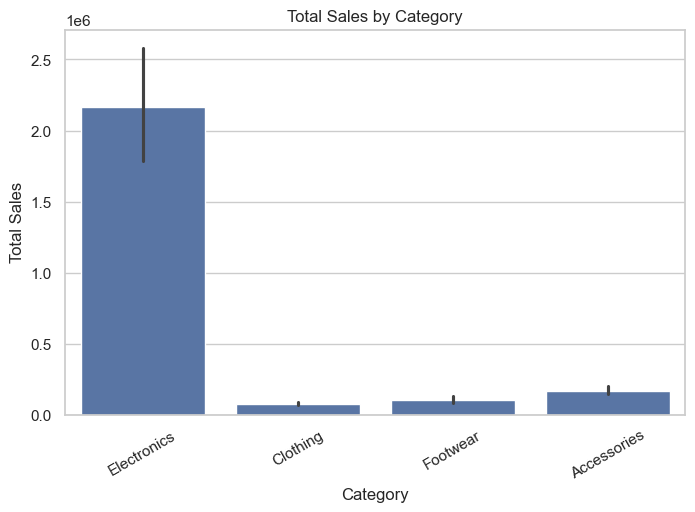

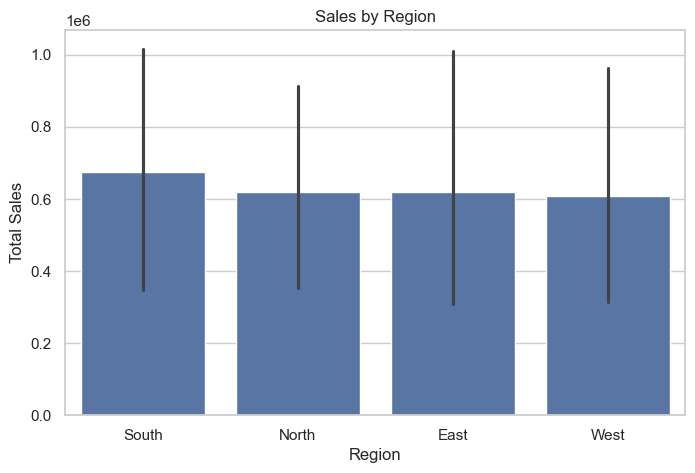

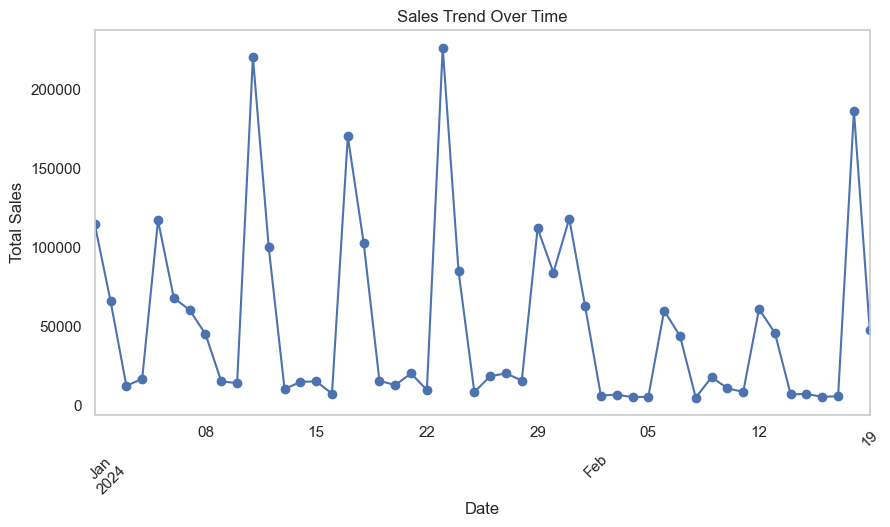

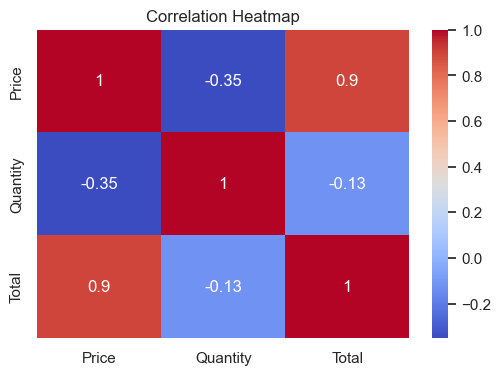


--- KEY INSIGHTS ---
1. Electronics contributes the highest revenue.
2. Sales fluctuate across regions.
3. Outliers are present in high-value transactions.
4. Price strongly influences total sales.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

data = pd.read_csv('sales_data.csv')

print("Initial Data:\n", data.head())

# Missing values
print("\nMissing Values:\n", data.isnull().sum())

# Fix (no inplace warning)
data['Quantity'] = data['Quantity'].fillna(data['Quantity'].median())

# Remove duplicates
data.drop_duplicates(inplace=True)

# Convert Date
data['Date'] = pd.to_datetime(data['Date'])

# Create Total column
data['Total'] = data['Price'] * data['Quantity']

print("\nCleaned Data:\n", data.head())

# OUTLIER DETECTION
plt.figure(figsize=(8,5))
sns.boxplot(x=data['Total'])
plt.title("Outlier Detection - Total Sales")
plt.xlabel("Total Sales")
plt.show()

# VISUALIZATION
# 1. Category-wise sales (TOTAL, not average)
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Total', data=data, estimator=sum)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.show()

# 2. Region-wise sales
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Total', data=data, estimator=sum)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

# 3. Sales trend
plt.figure(figsize=(10,5))
data.groupby('Date')['Total'].sum().plot(marker='o')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 4. Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# INSIGHTS

print("\n--- KEY INSIGHTS ---")
print("1. Electronics contributes the highest revenue.")
print("2. Sales fluctuate across regions.")
print("3. Outliers are present in high-value transactions.")
print("4. Price strongly influences total sales.")